In [1]:
import torch

from ProcessOptimizer.model_systems import gaussian_process_benchmark as gp_benchmark
from ProcessOptimizer import Optimizer

from ProcessOptimizer.learning import ExtraTreesRegressor
from ProcessOptimizer import Optimizer

 # Single Task Case

In [2]:
lower_bound = -1.5
upper_bound = 1.5

opt = Optimizer([(lower_bound, upper_bound)], "GP", acq_optimizer="sampling")
gp1 = gp_benchmark.GPExperiment(lower_bound, upper_bound)
print('min: %s'%(gp1.min))

path = {}

for idx_ in range(50):
    next = opt.ask()
    f_val = gp1.score(next[0])
    opt.tell(next, f_val)
    path[idx_] = [next[0], f_val]

min: -1.9516756534576416


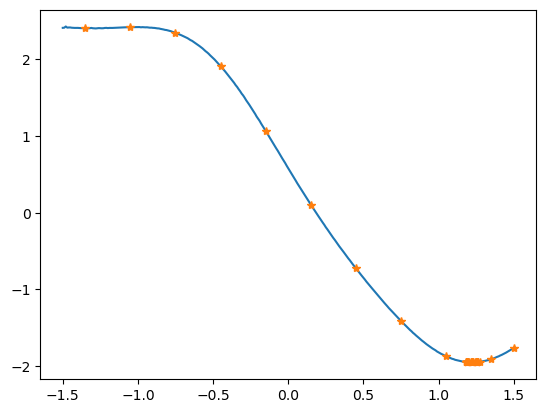

In [3]:
import matplotlib.pyplot as plt
plt.plot(gp1.domain, gp1.f_values);
plt.plot([val[0] for _, val in path.items()], [val[1] for _, val in path.items()], '*')

In [4]:
isinstance({'a'}, set)

True

# 1D 4 Tasks Learner

In [5]:
gp2 = gp_benchmark.GPExperiment(-1.5, 1.5, 4, 1.5, 0.5)

idx, train_x, train_y = gp2.get_sample(10)

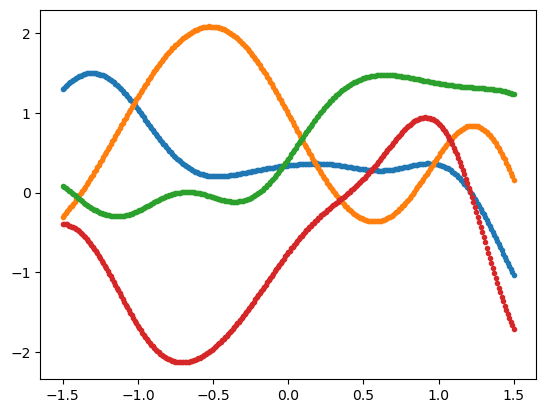

In [6]:
from matplotlib import pyplot as plt

plt.plot(gp2.domain, gp2.f_values, '.');

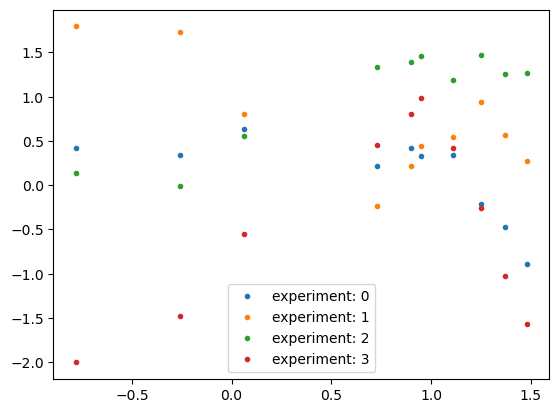

In [7]:
from matplotlib import pyplot as plt

for idx_ in range(train_y.shape[1]):
  plt.plot(train_x, train_y[:, idx_], '.', label='experiment: %s'%(idx_));

plt.legend();

In [8]:
train_y[...,0]

tensor([ 0.3354,  0.4199,  0.3436, -0.8930,  0.4241,  0.6374,  0.2123, -0.4741,
         0.3394, -0.2156])

In [9]:
train_x.reshape(-1, 1).shape

torch.Size([10, 1])

In [10]:
from ProcessOptimizer.learning import GaussianProcessRegressor
from ProcessOptimizer.learning.gaussian_process import kernels

kernel_ = kernels.ConstantKernel(constant_value=1.8)*kernels.RBF(length_scale=0.3)
gp = GaussianProcessRegressor(kernel=kernel_).fit(train_x.reshape(-1, 1), train_y[...,0])

/Users/bromia/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [11]:
gp.get_params()

{'alpha': 1e-10,
 'copy_X_train': True,
 'kernel__k1': 1.34**2,
 'kernel__k2': RBF(length_scale=0.3),
 'kernel__k1__constant_value': 1.8,
 'kernel__k1__constant_value_bounds': (1e-05, 100000.0),
 'kernel__k2__length_scale': 0.3,
 'kernel__k2__length_scale_bounds': (1e-05, 100000.0),
 'kernel': 1.34**2 * RBF(length_scale=0.3),
 'n_restarts_optimizer': 0,
 'noise': None,
 'noise_level_bounds': (1e-05, 100000.0),
 'normalize_y': False,
 'optimizer': 'fmin_l_bfgs_b',
 'random_state': None}

In [12]:
params = {
     'alpha': 1e-10,
     'copy_X_train': True,
     'kernel__k1': 1.34**2,
     'kernel__k2': kernels.RBF(length_scale=0.4),
     'kernel__k1__constant_value': 1.8,
     'kernel__k1__constant_value_bounds': (1e-05, 100000.0),
     'kernel__k2__length_scale': 0.3,
     'kernel__k2__length_scale_bounds': (1e-05, 100000.0),
     'kernel': 1.34**2 * kernels.RBF(length_scale=0.3),
     'n_restarts_optimizer': 0,
     'noise': None,
     'noise_level_bounds': (1e-05, 100000.0),
     'normalize_y': False,
     'optimizer': 'fmin_l_bfgs_b',
     'random_state': None
}

In [13]:
gp.set_params(**params)

GaussianProcessRegressor(kernel=1.7956000000000003 * RBF(length_scale=0.4))

In [6]:
from ProcessOptimizer.space import Categorical, Task, Dimension, Real, Integer, Space
from ProcessOptimizer import Optimizer
lower_bound = -1.5
upper_bound = 1.5

In [15]:
import ProcessOptimizer as op

In [2]:
from ProcessOptimizer.space import Categorical

In [13]:
Task([0, 1, 2, 3], active_task=1).sample([0., 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

array([0, 1, 1, 2, 2, 2, 3, 3, 0], dtype=object)

In [18]:
Task([0, 1, 2, 3], active_task=1).tasks.index(Task([0, 1, 2, 3], active_task=1).active_task)

1

In [4]:
task_space = Space([Real(lower_bound, upper_bound, name='grid'), Task([0, 1, 2, 3], active_task=0, name='tasks')])

In [18]:
opt2 = Optimizer(
    dimensions=task_space,
    base_estimator="GP", 
    n_initial_points=5,
    acq_func='EI',
    acq_optimizer="sampling",
    n_objectives=1)

In [19]:
opt2.base_estimator_ = gp

In [20]:
opt2.base_estimator_.kernel

1.7956000000000003 * RBF(length_scale=0.4)

In [21]:
train_x.reshape(-1, 1).tolist(), train_y[...,1].tolist()

([[0.949999988079071],
  [-0.7799999713897705],
  [1.1099998950958252],
  [1.4800000190734863],
  [0.8999999761581421],
  [0.05999999865889549],
  [0.7300000190734863],
  [1.3700000047683716],
  [-0.2600000202655792],
  [1.25]],
 [0.44652101397514343,
  1.7937923669815063,
  0.5464094281196594,
  0.2733922600746155,
  0.21765878796577454,
  0.7992472648620605,
  -0.23806466162204742,
  0.5721213817596436,
  1.7311874628067017,
  0.940116822719574])

In [22]:
#opt2.tell(train_x.reshape(-1, 1).tolist()[0], train_y[...,1].tolist())

In [23]:
# for idx_ in range(50):
#     next = opt2.ask()
#     f_val = gp2.score(next[0])
#     opt2.tell(next, f_val)
#     path[idx_] = [next[0], f_val]

# Task Class 

In [24]:
#**{str(key):val for key, val in path.items()}

In [25]:
# from ProcessOptimizer.utils import create_result
# 
# create_result()

In [26]:
print(task_space.is_categorical, task_space.is_task, task_space.is_partly_task)

False False True


In [17]:
for dim in task_space:
    print(type(dim))

<class 'ProcessOptimizer.space.space.Real'>
<class 'ProcessOptimizer.space.space.Task'>


In [19]:
task_space.rvs(10)

[[-0.562174097329274, 0],
 [-0.7196171053102456, 1],
 [-0.2293107419156306, 1],
 [-0.6118944958527156, 2],
 [1.3179360151769504, 3],
 [-0.8405620757282191, 1],
 [0.33540793027739557, 1],
 [-1.3834127402977638, 3],
 [1.0327829441740732, 1],
 [-0.565064755375723, 3]]

In [10]:
task_space
from ProcessOptimizer.space import check_dimension
print(check_dimension(task_space))

ValueError: Dimension has to be a list or tuple.

In [28]:
# opt = Optimizer(
#     space=task_space, "GP", n_initial_points = 10)

In [29]:
opt2.__dict__

{'rng': RandomState(MT19937) at 0x10DA41240,
 'n_objectives': 1,
 'acq_func': 'EI',
 'acq_func_kwargs': None,
 'cand_acq_funcs_': ['EI'],
 'eta': 1.0,
 '_n_initial_points': 5,
 'n_initial_points_': 5,
 '_length_scale_bounds': None,
 '_length_scale': None,
 'n_points': 10000,
 'n_restarts_optimizer': 5,
 'n_jobs': 1,
 'acq_optimizer_kwargs': {},
 'base_estimator_': GaussianProcessRegressor(kernel=1.7956000000000003 * RBF(length_scale=0.4)),
 'acq_optimizer': 'sampling',
 'space': Space([Real(low=-1.5, high=1.5, prior='uniform', transform='normalize'),
        Task(tasks=(0, 1, 2, 3), active_task=0, prior=None)]),
 '_lhs': True,
 '_lhs_samples': [[1.2000000000000002, 2],
  [0.0, 0],
  [0.5999999999999996, 1],
  [-0.6000000000000001, 2],
  [-1.2, 3]],
 '_constraints': None,
 '_cat_inds': [],
 '_non_cat_inds': [0, 1],
 'objective_name_list': ['Y'],
 'models': [],
 'Xi': [],
 'yi': [],
 'cache_': {}}

In [30]:
opt.ask(n_points = 10)

[[1.225959094000232],
 [-0.2910104601295136],
 [-0.04976855695850424],
 [-0.543556640618763],
 [-0.36103162182400106],
 [0.03615169013352926],
 [-0.6306607140365251],
 [-0.21525771468588473],
 [0.23084498260147823],
 [-0.6889230815807046]]

In [31]:
# samples = opt.ask(n_points = 10)
# samples = np.array(samples)
# samples

In [32]:
task = Task(list('abc'), 'a')

In [33]:
task.tasks

('a', 'b', 'c')

In [34]:
cat = Categorical(list('abc'))
cat.__dict__

{'categories': ('a', 'b', 'c'),
 '_name': None,
 'transform_': 'onehot',
 'transformer': <ProcessOptimizer.space.transformers.CategoricalEncoder at 0x139c5c4d0>,
 'prior': None,
 'prior_': array([0.33333333, 0.33333333, 0.33333333])}

In [35]:
task = Task(list('abc'), active_task='a')

In [36]:
task

Task(tasks=('a', 'b', 'c'), active_task=a, prior=None)

# XPyriMentor Implementation

In [37]:
from ProcessOptimizer import XpyriMentor 

In [38]:
task_space

Space([Real(low=-1.5, high=1.5, prior='uniform', transform='identity'),
       Task(tasks=(0, 1, 2, 3), active_task=0, prior=None)])

In [39]:
director = XpyriMentor(task_space)
print(director)

XpyriMentor with a SequentialStrategizer suggestor


In [40]:
# samples points from the search space 
first_suggested_params = director.ask(5)

In [41]:
first_suggested_params[0]

array([1.2000000000000002, 2], dtype=object)

In [42]:
first_suggested_params

array([[1.2000000000000002, 2],
       [0.0, 0],
       [0.5999999999999996, 1],
       [-0.6000000000000001, 2],
       [-1.2, 3]], dtype=object)

In [43]:
# evaluate points using oracle and pass them to suggestor

In [75]:
import torch 
import numpy as np

train_x = torch.from_numpy(np.array(first_suggested_params, dtype=np.float32))
train_x[:, 0].unsqueeze(1), train_x[:, 1].unsqueeze(1)

(tensor([[ 1.2000],
         [ 0.0000],
         [ 0.6000],
         [-0.6000],
         [-1.2000]]),
 tensor([[2.],
         [0.],
         [1.],
         [2.],
         [3.]]))

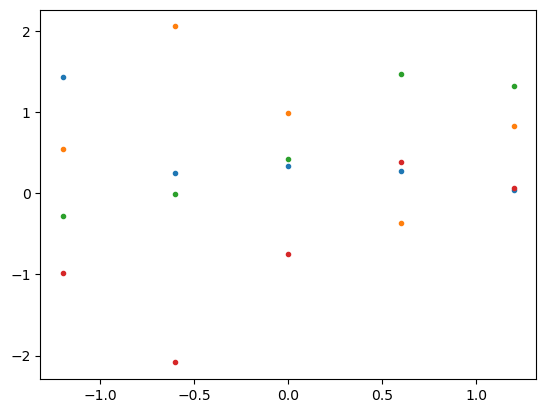

In [76]:

plt.plot(train_x[:, 0].unsqueeze(1), [gp2.score(itm_.item()) for itm_ in train_x[:, 0].unsqueeze(1)], '.');

In [46]:
director.tell(train_x[:, 0].unsqueeze(1), [gp2.score(itm_.item()) for itm_ in train_x[:, 0].unsqueeze(1)])

In [77]:
second_suggested_params = director.ask(4)
print(second_suggested_params)

[tensor([[ 1.2000],
        [ 0.0000],
        [ 0.6000],
        [-0.6000],
        [-1.2000]]), tensor([[ 1.2000],
        [ 0.0000],
        [ 0.6000],
        [-0.6000],
        [-1.2000]])] [tensor([[ 0.3354],
        [ 0.4199],
        [ 0.3436],
        [-0.8930],
        [ 0.4241],
        [ 0.6374],
        [ 0.2123],
        [-0.4741],
        [ 0.3394],
        [-0.2156]]), tensor([[ 0.3354],
        [ 0.4199],
        [ 0.3436],
        [-0.8930],
        [ 0.4241],
        [ 0.6374],
        [ 0.2123],
        [-0.4741],
        [ 0.3394],
        [-0.2156]])]


/Users/bromia/projects/ProcessOptimizer/ProcessOptimizer/XpyriMentor/suggestors/multitask_suggestor.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_x = torch.tensor(Xi, dtype=torch.float64)
/Users/bromia/projects/ProcessOptimizer/ProcessOptimizer/XpyriMentor/suggestors/multitask_suggestor.py:112: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_y = torch.tensor(Yi, dtype=torch.float64).reshape(-1, 1)


AttributeError: 'NoneType' object has no attribute 'get'

In [48]:
suggestor_definition = {
    "suggestor_name": "Sequential",
    "suggestors": [
        {"suggestor_budget": 7, "suggestor_name": "LHS"},
        {
            "suggestor_budget": 20,
            "suggestor_name": "Random",
            "suggestors": [
                {
                    "suggestor_usage_ratio": 80,
                    "suggestor_name": "PO",
                    "acq_func_kwargs": {"xi": 10},
                },
                {
                    "suggestor_usage_ratio": 20,
                    "suggestor_name": "PO",
                    "acq_func_kwargs": {"xi": 0.00001},
                },
            ],
        },
        {
            "suggestor_budget": float("inf"),
            "suggestor_name": "PO",
            "acq_func_kwargs": {"xi": 0.00001}
        },
    ]
}

director = XpyriMentor(task_space, suggestor_definition)
intial_suggestions = director.ask(5)
director.tell(intial_suggestions, [0.5, 0.6, -0.7, 0.8, 0.9])
print(director.ask(10))

[[0.8571428571428572 2]
 [-1.2857142857142858 3]
 [-1.4986060421756353 3]
 [0.8315816139712315 2]
 [-1.1452379652742692 0]
 [0.21143981379676546 0]
 [-0.635052908209743 2]
 [1.0408861406608603 0]
 [-0.0946990128727141 3]
 [-1.3548991928175862 1]]


In [49]:
suggestor_definition = {
    "suggestor_name": "Sequential",
    "suggestors": [
        {"suggestor_budget": 7, "suggestor_name": "LHS"},
        {
            "suggestor_budget": 20,
            "suggestor_name": "Random",
            "suggestors": [
                {
                    "suggestor_usage_ratio": 80,
                    "suggestor_name": "PO",
                    "acq_func_kwargs": {"xi": 10},
                },
                {
                    "suggestor_usage_ratio": 20,
                    "suggestor_name": "PO",
                    "acq_func_kwargs": {"xi": 0.00001},
                },
            ],
        },
        {
            "suggestor_budget": float("inf"),
            "suggestor_name": "PO",
            "acq_func_kwargs": {"xi": 0.00001}
        },
    ]
}

In [50]:
from ProcessOptimizer.XpyriMentor.suggestors import MTSuggestor

In [51]:
suggestor = MTSuggestor(task_space, 1, 42)

In [54]:
task_space

Space([Real(low=-1.5, high=1.5, prior='uniform', transform='identity'),
       Task(tasks=(0, 1, 2, 3), active_task=0, prior=None)])

In [124]:
task_space.__dict__

{'dimensions': [Real(low=-1.5, high=1.5, prior='uniform', transform='identity'),
  Task(tasks=(0, 1, 2, 3), active_task=0, prior=None)]}

In [83]:
objective_fcn =lambda tens_: [gp2.score(itm_.item()) for itm_ in tens_]
train_y = objective_fcn(train_x[:, 0].unsqueeze(1))

In [52]:
director = XpyriMentor(task_space, suggestor)

In [84]:
director.tell(train_x[:, 0].unsqueeze(1), train_y[:, 0].unsqueeze(1))

TypeError: list indices must be integers or slices, not tuple

In [55]:
director.tell(train_x[:, 0].unsqueeze(1), train_y[:, 0].unsqueeze(1))

In [117]:
Xi = [torch.split(train_x, 1, 1)[0].squeeze().tolist(), torch.split(train_x, 1, 1)[1].squeeze().tolist()] 
Xi

[[1.2000000476837158,
  0.0,
  0.6000000238418579,
  -0.6000000238418579,
  -1.2000000476837158],
 [2.0, 0.0, 1.0, 2.0, 3.0]]

In [88]:
suggestor.initialise_model(torch.split(train_x, 1, 1)[0].squeeze().tolist(), )

[[0.039318669587373734,
  0.8337090015411377,
  1.321958065032959,
  0.061892975121736526],
 [0.3401166498661041,
  0.9891400933265686,
  0.4246576130390167,
  -0.7501897215843201],
 [0.2760511338710785,
  -0.36219820380210876,
  1.4714075326919556,
  0.3867112696170807],
 [0.24481436610221863,
  2.05410099029541,
  -0.007630222477018833,
  -2.0841453075408936],
 [1.4365596771240234,
  0.5438088774681091,
  -0.28266778588294983,
  -0.9851981401443481]]

In [56]:
director.ask()

[tensor([[ 1.2000],
        [ 0.0000],
        [ 0.6000],
        [-0.6000],
        [-1.2000]]), tensor([[ 1.2000],
        [ 0.0000],
        [ 0.6000],
        [-0.6000],
        [-1.2000]])] [tensor([[ 0.3354],
        [ 0.4199],
        [ 0.3436],
        [-0.8930],
        [ 0.4241],
        [ 0.6374],
        [ 0.2123],
        [-0.4741],
        [ 0.3394],
        [-0.2156]]), tensor([[ 0.3354],
        [ 0.4199],
        [ 0.3436],
        [-0.8930],
        [ 0.4241],
        [ 0.6374],
        [ 0.2123],
        [-0.4741],
        [ 0.3394],
        [-0.2156]])]


/Users/bromia/projects/ProcessOptimizer/ProcessOptimizer/XpyriMentor/suggestors/multitask_suggestor.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_x = torch.tensor(Xi, dtype=torch.float64)
/Users/bromia/projects/ProcessOptimizer/ProcessOptimizer/XpyriMentor/suggestors/multitask_suggestor.py:112: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_y = torch.tensor(Yi, dtype=torch.float64).reshape(-1, 1)


AttributeError: 'NoneType' object has no attribute 'get'

In [57]:
type(director.Xi), type(director.yi)

(list, list)

In [74]:
train_x[:, 0].unsqueeze(1).squeeze()

tensor([ 1.2000,  0.0000,  0.6000, -0.6000, -1.2000])

In [ ]:
train_y.split

In [73]:
train_y[:, 0].squeeze().tolist()

[0.33544084429740906,
 0.41989368200302124,
 0.3436167240142822,
 -0.8929551243782043,
 0.424050897359848,
 0.6373835206031799,
 0.2122926115989685,
 -0.4741336405277252,
 0.33942028880119324,
 -0.21561916172504425]

In [119]:
Xi, task_space.transform(Xi)

([[1.2000000476837158,
   0.0,
   0.6000000238418579,
   -0.6000000238418579,
   -1.2000000476837158],
  [2.0, 0.0, 1.0, 2.0, 3.0]],
 array([[1.20000005, 1.        , 0.        , 0.        , 0.        ],
        [2.        , 1.        , 0.        , 0.        , 0.        ]]))

In [120]:
task_space

Space([Real(low=-1.5, high=1.5, prior='uniform', transform='identity'),
       Task(tasks=(0, 1, 2, 3), active_task=0, prior=None)])

In [59]:
director.Xi[0].clone().detach()

tensor([[ 1.2000],
        [ 0.0000],
        [ 0.6000],
        [-0.6000],
        [-1.2000]])